In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from data_loading import clean_datasets, load_motor_temps
import torch
import torch.nn as nn
import itertools
import time
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon


## Data-Loading and Training Folds

In [2]:
DATASET_CONFIG = {
    "motor-temp":         {"window": 75,  "transform": "diff",        "n_folds": 5},
    "wind-power":          {"window": 36,  "transform": "diff",        "n_folds": 5},
    "store-sales":         {"window": 7,   "transform": "log1p_diff",  "n_folds": 5},
    "antarctica-climate":  {"window": 30,  "transform": "diff",        "n_folds": 5},
    "traffic":             {"window": 24,  "transform": "diff",        "n_folds": 5},
}

SEASONAL_LAG_CONFIG = {
    "traffic": 168,             # 1 week at hourly resolution
    "antarctica-climate": 365,  # 1 year at daily resolution
    "wind-power": 144,          # 1 day at 10-min resolution
}

SERIES = clean_datasets()

In [34]:
def apply_transform(series, transform):
    s = series.dropna()
    if transform == "log1p_diff":
        s = np.log1p(s)
        return s.diff().dropna()
    elif transform == "diff":
        return s.diff().dropna()
    elif transform == "none":
        return s
    else:
        raise ValueError(f"unknown transform: {transform}")

In [35]:
TRANSFORMED_FINAL = {}
for name, s in SERIES.items():
    cfg = DATASET_CONFIG[name]
    TRANSFORMED_FINAL[name] = apply_transform(s, cfg["transform"])
    print(f"{name}: transform='{cfg['transform']}', n={len(TRANSFORMED_FINAL[name])}")


motor-temp: transform='diff', n=43970
wind-power: transform='diff', n=5038
store-sales: transform='log1p_diff', n=1457
antarctica-climate: transform='diff', n=7304
traffic: transform='diff', n=17543


In [36]:
def make_windows(values, window):
    """
    values: 1D numpy array
    window: number of past steps used to predict the next step
    Returns X of shape (n_samples, window, 1), y of shape (n_samples,)
    """
    X, y = [], []
    for i in range(len(values) - window):
        X.append(values[i : i + window])
        y.append(values[i + window])
    X = np.array(X).reshape(-1, window, 1)
    y = np.array(y)
    return X, y

In [37]:
def make_windows_multivariate(df, target_col, feature_cols, window):
    """
    df: DataFrame with target_col and feature_cols aligned on the same index
    Returns X of shape (n_samples, window, n_features), y of shape (n_samples,)
    """
    values = df[[target_col] + feature_cols].values
    X, y = [], []
    for i in range(len(values) - window):
        X.append(values[i : i + window])
        y.append(values[i + window, 0])
    return np.array(X), np.array(y)

In [38]:
def make_windows_with_seasonal_lag(values, window, seasonal_lag):
    """
    X has 2 channels, recent window and window at a seasonal lag
    Returns None, None if the series isn't long enough for the requested seasonal_lag.
    """
    n = len(values)
    if n <= window + seasonal_lag:
        print(f"  series too short for seasonal_lag={seasonal_lag} (need > {window + seasonal_lag}, have {n})")
        return None, None

    X, y = [], []
    for i in range(seasonal_lag, n - window):
        window_vals = values[i : i + window]
        seasonal_vals = values[i - seasonal_lag : i - seasonal_lag + window]
        X.append(np.stack([window_vals, seasonal_vals], axis=-1))
        y.append(values[i + window])
    return np.array(X), np.array(y)

In [39]:
def walk_forward_splits(n_samples, n_folds, min_train_fraction=0.4):
    """
    Yields (train_idx, val_idx) index ranges for expanding-window walk-forward CV.
    min_train_fraction: fraction of data used as the initial training block.
    Remaining data is split into n_folds equal validation chunks, each fold's
    training set expanding to include all prior folds' data.
    """
    min_train_size = int(n_samples * min_train_fraction)
    remaining = n_samples - min_train_size
    fold_size = remaining // n_folds

    splits = []
    for fold in range(n_folds):
        train_end = min_train_size + fold * fold_size
        val_start = train_end
        val_end = val_start + fold_size if fold < n_folds - 1 else n_samples
        splits.append((np.arange(0, train_end), np.arange(val_start, val_end)))
    return splits

In [40]:
# Checking the seasonal lags work fine
for name in ["traffic", "antarctica-climate", "wind-power"]:
    cfg = DATASET_CONFIG[name]
    values = TRANSFORMED_FINAL[name].values.astype(np.float64)
    seasonal_lag = SEASONAL_LAG_CONFIG[name]

    X, y = make_windows_with_seasonal_lag(values, cfg["window"], seasonal_lag)
    if X is not None:
        print(f"{name}: X shape={X.shape} (2 channels: recent + seasonal-lag-{seasonal_lag})")

traffic: X shape=(17351, 24, 2) (2 channels: recent + seasonal-lag-168)
antarctica-climate: X shape=(6909, 30, 2) (2 channels: recent + seasonal-lag-365)
wind-power: X shape=(4858, 36, 2) (2 channels: recent + seasonal-lag-144)


In [41]:
PREPARED = {}

for name, series in TRANSFORMED_FINAL.items():
    cfg = DATASET_CONFIG[name]
    values = series.values.astype(np.float64)

    # Seasonal lags added to window for the three specified datasets
    if name in ["traffic", "antarctica-climate", "wind-power"]:
        seasonal_lag = SEASONAL_LAG_CONFIG[name]
        X, y = make_windows_with_seasonal_lag(values, cfg["window"], seasonal_lag)
    else:
        X, y = make_windows(values, cfg["window"])

    splits = walk_forward_splits(len(X), cfg["n_folds"])

    fold_data = []
    for fold_i, (train_idx, val_idx) in enumerate(splits):
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        # fit scaler on training data
        scaler = MinMaxScaler(feature_range=(-1, 1))
        scaler.fit(X_train.reshape(-1, 1))

        X_train_scaled = scaler.transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
        X_val_scaled   = scaler.transform(X_val.reshape(-1, 1)).reshape(X_val.shape)
        y_train_scaled = scaler.transform(y_train.reshape(-1, 1)).flatten()
        y_val_scaled   = scaler.transform(y_val.reshape(-1, 1)).flatten()

        fold_data.append({
            "X_train": X_train_scaled, "y_train": y_train_scaled,
            "X_val": X_val_scaled,     "y_val": y_val_scaled,
            "scaler": scaler,
            "train_size": len(train_idx), "val_size": len(val_idx),
        })

    PREPARED[name] = fold_data

    print(f"\n{name}: window={cfg['window']}, total windows={len(X)}, folds={cfg['n_folds']}")
    for i, f in enumerate(fold_data):
        print(f"  fold {i}: train={f['train_size']}, val={f['val_size']}")


motor-temp: window=75, total windows=43895, folds=5
  fold 0: train=17558, val=5267
  fold 1: train=22825, val=5267
  fold 2: train=28092, val=5267
  fold 3: train=33359, val=5267
  fold 4: train=38626, val=5269

wind-power: window=36, total windows=4858, folds=5
  fold 0: train=1943, val=583
  fold 1: train=2526, val=583
  fold 2: train=3109, val=583
  fold 3: train=3692, val=583
  fold 4: train=4275, val=583

store-sales: window=7, total windows=1450, folds=5
  fold 0: train=580, val=174
  fold 1: train=754, val=174
  fold 2: train=928, val=174
  fold 3: train=1102, val=174
  fold 4: train=1276, val=174

antarctica-climate: window=30, total windows=6909, folds=5
  fold 0: train=2763, val=829
  fold 1: train=3592, val=829
  fold 2: train=4421, val=829
  fold 3: train=5250, val=829
  fold 4: train=6079, val=830

traffic: window=24, total windows=17351, folds=5
  fold 0: train=6940, val=2082
  fold 1: train=9022, val=2082
  fold 2: train=11104, val=2082
  fold 3: train=13186, val=2082


In [42]:
# Checking no NaN's in dataset
for name, folds in PREPARED.items():
    for i, f in enumerate(folds):
        bad = (np.isnan(f["X_train"]).any() or np.isnan(f["y_train"]).any()
               or np.isinf(f["X_train"]).any() or np.isinf(f["y_train"]).any())
        if bad:
            print(f"⚠ {name} fold {i}: NaN/Inf detected")
print("NaN/Inf check complete")

# Checking the ranges look correct
for name, folds in PREPARED.items():
    f = folds[-1]
    print(f"{name}: y_train range=({f['y_train'].min():.2f}, {f['y_train'].max():.2f}), "
          f"y_val range=({f['y_val'].min():.2f}, {f['y_val'].max():.2f})")

NaN/Inf check complete
motor-temp: y_train range=(-1.00, 1.00), y_val range=(-0.65, 0.16)
wind-power: y_train range=(-1.00, 1.00), y_val range=(-0.55, 0.56)
store-sales: y_train range=(-1.00, 1.00), y_val range=(-0.92, 0.90)
antarctica-climate: y_train range=(-1.00, 1.00), y_val range=(-0.66, 0.65)
traffic: y_train range=(-1.00, 1.00), y_val range=(-0.97, 1.37)


## Modelling

### Class Definition

In [3]:
# ---------------------------------------------------------------
# Elman Network — feedback from previous HIDDEN state
# (equivalent to nn.RNN, but written explicitly so it can be
#  described precisely in the report and kept consistent in
#  style with Jordan/MRN below)
# ---------------------------------------------------------------
class ElmanNet(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_in = nn.Linear(input_size, hidden_size)
        self.W_context = nn.Linear(hidden_size, hidden_size)
        self.W_out = nn.Linear(hidden_size, output_size)
        self.activation = nn.Tanh()

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)

        for t in range(seq_len):
            h = self.activation(self.W_in(x[:, t, :]) + self.W_context(h))
            # context units simply ARE h at the next step — no separate state needed

        out = self.W_out(h)
        return out.squeeze(-1)


# ---------------------------------------------------------------
# Jordan Network — feedback from previous OUTPUT
# ---------------------------------------------------------------
class JordanNet(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.W_in = nn.Linear(input_size, hidden_size)
        self.W_context = nn.Linear(output_size, hidden_size)
        self.W_out = nn.Linear(hidden_size, output_size)
        self.activation = nn.Tanh()

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        y_prev = torch.zeros(batch_size, self.output_size, device=x.device)

        for t in range(seq_len):
            h = self.activation(self.W_in(x[:, t, :]) + self.W_context(y_prev))
            y_prev = self.W_out(h)  # context is the network's own previous output

        return y_prev.squeeze(-1)


# ---------------------------------------------------------------
# Multi-Recurrent Network — feedback from BOTH hidden state and
# output, with a self-recurrent decay parameter on the context
# units for multi-timescale memory (Elman + Jordan generalized)
# ---------------------------------------------------------------
class MultiRecurrentNet(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1, decay=0.5):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.decay = decay  # controls how much of the PAST context persists

        self.W_in = nn.Linear(input_size, hidden_size)
        self.W_hidden_context = nn.Linear(hidden_size, hidden_size)
        self.W_output_context = nn.Linear(output_size, hidden_size)
        self.W_out = nn.Linear(hidden_size, output_size)
        self.activation = nn.Tanh()

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        y_prev = torch.zeros(batch_size, self.output_size, device=x.device)
        context_h = torch.zeros(batch_size, self.hidden_size, device=x.device)

        for t in range(seq_len):
            # self-recurrent context: decayed mix of past context + new hidden activation
            context_h = self.decay * context_h + (1 - self.decay) * h
            h = self.activation(
                self.W_in(x[:, t, :])
                + self.W_hidden_context(context_h)
                + self.W_output_context(y_prev)
            )
            y_prev = self.W_out(h)

        return y_prev.squeeze(-1)

In [4]:
def train_model(model, X_train, y_train, X_val, y_val,
                 lr=1e-3, weight_decay=1e-4, max_epochs=200, patience=15, device="cpu"):

    model = model.to(device)
    X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    X_val_t   = torch.tensor(X_val,   dtype=torch.float32, device=device)
    y_val_t   = torch.tensor(y_val,   dtype=torch.float32, device=device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train_t)
        loss = loss_fn(pred, y_train_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # guards against exploding gradients
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = loss_fn(val_pred, y_val_t).item()

        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return model, history, best_val_loss

### Architecture Test

Smoke test: ElmanNet on 'motor-temp', fold 0
X_train shape: (17558, 75, 1), y_train shape: (17558,)
X_val shape:   (5267, 75, 1), y_val shape:   (5267,)
  early stopping at epoch 39

Done in 6.7s, 40 epochs run
Best val loss: 0.010290
Final train loss: 0.007226


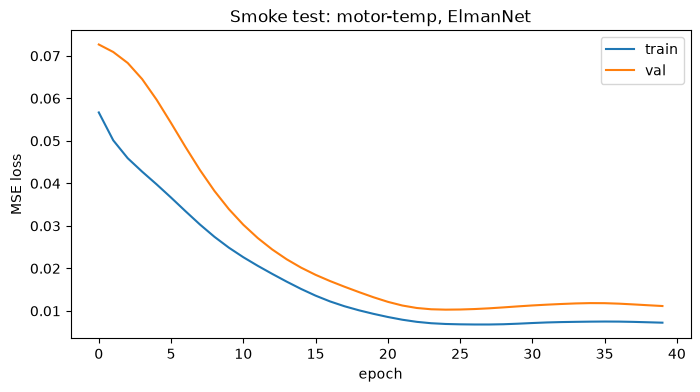


Naive (predict-zero) baseline val MSE: 0.114407
Model val MSE:                          0.010290
Model beats the naive baseline


In [45]:
# ---------------------------------------------------------------
# Smoke test: one architecture, one dataset, one fold
# ---------------------------------------------------------------
name = "motor-temp"
fold = PREPARED[name][0]

print(f"Smoke test: ElmanNet on '{name}', fold 0")
print(f"X_train shape: {fold['X_train'].shape}, y_train shape: {fold['y_train'].shape}")
print(f"X_val shape:   {fold['X_val'].shape}, y_val shape:   {fold['y_val'].shape}")

model = ElmanNet(input_size=1, hidden_size=32, output_size=1)

start = time.time()
trained_model, history, best_val_loss = train_model(
    model,
    fold["X_train"], fold["y_train"],
    fold["X_val"], fold["y_val"],
    lr=1e-3, weight_decay=1e-4,
    max_epochs=200, patience=15,
)
elapsed = time.time() - start

print(f"\nDone in {elapsed:.1f}s, {len(history['train_loss'])} epochs run")
print(f"Best val loss: {best_val_loss:.6f}")
print(f"Final train loss: {history['train_loss'][-1]:.6f}")

# quick sanity plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.legend()
plt.title(f"Smoke test: {name}, ElmanNet")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.show()

# a second sanity check: does the model actually beat a naive baseline?
# naive baseline: predict "no change" (0, since data is differenced)
naive_val_loss = np.mean(fold["y_val"] ** 2)
print(f"\nNaive (predict-zero) baseline val MSE: {naive_val_loss:.6f}")
print(f"Model val MSE:                          {best_val_loss:.6f}")
print(f"Model {'beats' if best_val_loss < naive_val_loss else 'DOES NOT beat'} the naive baseline")

### Hyperparameter Search and Walk-Forward Evaluation (No Seasonal Lags nor features added saved in Results_Raw.csv)

In [5]:
# ---------------------------------------------------------------
# 1. Model registry — architecture name -> class + which kwargs it accepts
# ---------------------------------------------------------------
ARCHITECTURES = {
    "elman": ElmanNet,
    "jordan": JordanNet,
    "mrn": MultiRecurrentNet,
}

# ---------------------------------------------------------------
# 2. Hyperparameter grid
# ---------------------------------------------------------------
HIDDEN_SIZES = [16, 32, 64]
WEIGHT_DECAYS = [0.0, 1e-4, 1e-3]
MRN_DECAYS = [0.3, 0.5, 0.7]

In [11]:
def build_model(arch_name, input_size, hidden_size, decay=0.5):
    cls = ARCHITECTURES[arch_name]
    if arch_name == "mrn":
        return cls(input_size=input_size, hidden_size=hidden_size, output_size=1, decay=decay)
    else:
        return cls(input_size=input_size, hidden_size=hidden_size, output_size=1)


def hyperparam_search(arch_name, dataset_name, fold0, max_epochs=150, patience=10):
    best_cfg, best_loss = None, float("inf")
    input_size = fold0["X_train"].shape[-1]   # infer from the actual data, not assumed

    if arch_name == "mrn":
        grid = list(itertools.product(HIDDEN_SIZES, WEIGHT_DECAYS, MRN_DECAYS))
    else:
        grid = [(h, wd, None) for h, wd in itertools.product(HIDDEN_SIZES, WEIGHT_DECAYS)]

    for hidden_size, weight_decay, decay in grid:
        model = build_model(arch_name, input_size, hidden_size, decay if decay is not None else 0.5)
        _, _, val_loss = train_model(
            model, fold0["X_train"], fold0["y_train"], fold0["X_val"], fold0["y_val"],
            lr=1e-3, weight_decay=weight_decay, max_epochs=max_epochs, patience=patience,
        )
        if val_loss < best_loss:
            best_loss = val_loss
            best_cfg = {"input_size": input_size, "hidden_size": hidden_size,
                        "weight_decay": weight_decay, "decay": decay}

    return best_cfg, best_loss

In [48]:
# ---------------------------------------------------------------
# Full experiment: for each dataset x architecture, search hyperparams
#    once, then retrain and evaluate with that config across all folds.
# ---------------------------------------------------------------
RESULTS = []          # flat list of per-fold results, for stats testing
BEST_CONFIGS = {}      # (dataset, arch) -> chosen hyperparameters

overall_start = time.time()

for dataset_name, folds in PREPARED.items():
    for arch_name in ARCHITECTURES:
        print(f"\n{'='*60}\n{dataset_name} | {arch_name}\n{'='*60}")

        # --- hyperparameter search on fold 0 ---
        t0 = time.time()
        best_cfg, search_val_loss = hyperparam_search(arch_name, dataset_name, folds[0])
        BEST_CONFIGS[(dataset_name, arch_name)] = best_cfg
        print(f"  best config: {best_cfg} (search val loss={search_val_loss:.6f}, "
              f"took {time.time()-t0:.1f}s)")

        # --- evaluate chosen config across ALL folds ---
        for fold_i, fold in enumerate(folds):
            model = build_model(
                arch_name,
                best_cfg["input_size"],
                best_cfg["hidden_size"],
                best_cfg["decay"] if best_cfg["decay"] is not None else 0.5,
            )

            trained_model, history, val_loss = train_model(
                model, fold["X_train"], fold["y_train"], fold["X_val"], fold["y_val"],
                lr=1e-3, weight_decay=best_cfg["weight_decay"],
                max_epochs=200, patience=15,
            )

            # compute additional metrics beyond MSE for reporting
            with torch.no_grad():
                X_val_t = torch.tensor(fold["X_val"], dtype=torch.float32)
                y_val_t = torch.tensor(fold["y_val"], dtype=torch.float32)
                pred = trained_model(X_val_t).numpy()

            mse = np.mean((pred - fold["y_val"]) ** 2)
            mae = np.mean(np.abs(pred - fold["y_val"]))
            rmse = np.sqrt(mse)

            RESULTS.append({
                "dataset": dataset_name, "arch": arch_name, "fold": fold_i,
                "mse": mse, "mae": mae, "rmse": rmse,
                "hidden_size": best_cfg["hidden_size"],
                "weight_decay": best_cfg["weight_decay"],
                "decay": best_cfg["decay"],
            })
            print(f"    fold {fold_i}: MSE={mse:.6f}, MAE={mae:.6f}, RMSE={rmse:.6f}")

print(f"\n\nTotal time: {(time.time()-overall_start)/60:.1f} minutes")

RESULTS_DF = pd.DataFrame(RESULTS)
RESULTS_DF.to_csv("results_seasonal_lags.csv", index=False)
print("\nSaved to results_seasonal_lags.csv")


motor-temp | elman
  early stopping at epoch 23
  early stopping at epoch 49
  early stopping at epoch 44
  early stopping at epoch 85
  early stopping at epoch 19
  early stopping at epoch 34
  early stopping at epoch 25
  best config: {'input_size': 1, 'hidden_size': 32, 'weight_decay': 0.001, 'decay': None} (search val loss=0.010086, took 91.8s)
  early stopping at epoch 47
    fold 0: MSE=0.009945, MAE=0.072999, RMSE=0.099727
  early stopping at epoch 43
    fold 1: MSE=0.004514, MAE=0.051412, RMSE=0.067190
  early stopping at epoch 49
    fold 2: MSE=0.005780, MAE=0.059455, RMSE=0.076024
  early stopping at epoch 79
    fold 3: MSE=0.005663, MAE=0.057484, RMSE=0.075252
  early stopping at epoch 32
    fold 4: MSE=0.005811, MAE=0.060000, RMSE=0.076230

motor-temp | jordan
  early stopping at epoch 93
  early stopping at epoch 78
  early stopping at epoch 104
  early stopping at epoch 18
  early stopping at epoch 98
  early stopping at epoch 77
  best config: {'input_size': 1, 'hid

### Leave One Population Out method for Motor Temp

In [6]:
WINDOW = DATASET_CONFIG["motor-temp"]["window"]

In [7]:
def build_profile_series(df, profile_id, target_col="pm"):
    """Extract and differences one profile's series, respecting its own boundaries."""
    sub = df[df["profile_id"] == profile_id][target_col].reset_index(drop=True)
    return sub.diff().dropna() 

def windows_for_profile(series, window):
    values = series.values.astype(np.float64)
    X, y = [], []
    for i in range(len(values) - window):
        X.append(values[i : i + window])
        y.append(values[i + window])
    if len(X) == 0:
        return np.empty((0, window, 1)), np.empty((0,))
    return np.array(X).reshape(-1, window, 1), np.array(y)

In [8]:
POPULATION_PROFILES = [20, 6, 65, 18, 66]
motors_raw_df = load_motor_temps()

# build windowed (X, y) per profile, kept separate for now
PROFILE_WINDOWS = {}
for pid in POPULATION_PROFILES:
    s = build_profile_series(motors_raw_df, pid)
    X, y = windows_for_profile(s, WINDOW)
    PROFILE_WINDOWS[pid] = {"X": X, "y": y}
    print(f"profile {pid}: {len(s)} points -> {len(X)} windows")

profile 20: 43970 points -> 43895 windows
profile 6: 40387 points -> 40312 windows
profile 65: 40093 points -> 40018 windows
profile 18: 37731 points -> 37656 windows
profile 66: 36475 points -> 36400 windows


In [9]:
def run_lopo_cv(arch_name, hidden_size, weight_decay, decay=0.5):
    fold_results = []

    for held_out in POPULATION_PROFILES:
        train_profiles = [p for p in POPULATION_PROFILES if p != held_out]

        X_train = np.concatenate([PROFILE_WINDOWS[p]["X"] for p in train_profiles], axis=0)
        y_train = np.concatenate([PROFILE_WINDOWS[p]["y"] for p in train_profiles], axis=0)
        X_val = PROFILE_WINDOWS[held_out]["X"]
        y_val = PROFILE_WINDOWS[held_out]["y"]

        # scaler fit only on training profiles — held-out profile never seen
        scaler = MinMaxScaler(feature_range=(-1, 1))
        scaler.fit(X_train.reshape(-1, 1))

        X_train_s = scaler.transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
        X_val_s   = scaler.transform(X_val.reshape(-1, 1)).reshape(X_val.shape)
        y_train_s = scaler.transform(y_train.reshape(-1, 1)).flatten()
        y_val_s   = scaler.transform(y_val.reshape(-1, 1)).flatten()

        model = build_model(arch_name, input_size=1, hidden_size=hidden_size, decay=decay)
        trained_model, history, val_loss = train_model(
            model, X_train_s, y_train_s, X_val_s, y_val_s,
            lr=1e-3, weight_decay=weight_decay, max_epochs=200, patience=15,
        )

        with torch.no_grad():
            pred = trained_model(torch.tensor(X_val_s, dtype=torch.float32)).numpy()
        mse = np.mean((pred - y_val_s) ** 2)
        mae = np.mean(np.abs(pred - y_val_s))

        fold_results.append({
            "held_out_profile": held_out, "train_profiles": train_profiles,
            "mse": mse, "mae": mae, "n_train": len(X_train), "n_val": len(X_val),
        })
        print(f"  held out profile {held_out}: MSE={mse:.6f}, MAE={mae:.6f} "
              f"(trained on {len(X_train)} windows from {train_profiles})")

    return pd.DataFrame(fold_results)

#### Single Architecture Test

In [12]:
lopo_results = run_lopo_cv("elman", hidden_size=32, weight_decay=1e-4)
print("\n", lopo_results)

  early stopping at epoch 20
  held out profile 20: MSE=0.000072, MAE=0.007437 (trained on 154386 windows from [6, 65, 18, 66])
  early stopping at epoch 76
  held out profile 6: MSE=0.000034, MAE=0.004260 (trained on 157969 windows from [20, 65, 18, 66])
  early stopping at epoch 38
  held out profile 65: MSE=0.004461, MAE=0.031620 (trained on 158263 windows from [20, 6, 18, 66])
  early stopping at epoch 45
  held out profile 18: MSE=0.000074, MAE=0.006433 (trained on 160625 windows from [20, 6, 65, 66])
  held out profile 66: MSE=0.002342, MAE=0.019399 (trained on 161881 windows from [20, 6, 65, 18])

    held_out_profile    train_profiles       mse       mae  n_train  n_val
0                20   [6, 65, 18, 66]  0.000072  0.007437   154386  43895
1                 6  [20, 65, 18, 66]  0.000034  0.004260   157969  40312
2                65   [20, 6, 18, 66]  0.004461  0.031620   158263  40018
3                18   [20, 6, 65, 66]  0.000074  0.006433   160625  37656
4                

#### Full Test

In [13]:
lopo_all_results = []
for arch_name in ARCHITECTURES:
    print(f"\n=== {arch_name} ===")
    df = run_lopo_cv(arch_name, hidden_size=32, weight_decay=1e-4)
    df["arch"] = arch_name
    lopo_all_results.append(df)

lopo_all_df = pd.concat(lopo_all_results, ignore_index=True)
lopo_all_df.to_csv("motor_temp_LOPO.csv", index=False)


=== elman ===
  early stopping at epoch 37
  held out profile 20: MSE=0.000056, MAE=0.005489 (trained on 154386 windows from [6, 65, 18, 66])
  early stopping at epoch 23
  held out profile 6: MSE=0.000041, MAE=0.004661 (trained on 157969 windows from [20, 65, 18, 66])
  early stopping at epoch 19
  held out profile 65: MSE=0.003618, MAE=0.027664 (trained on 158263 windows from [20, 6, 18, 66])
  early stopping at epoch 15
  held out profile 18: MSE=0.000082, MAE=0.006716 (trained on 160625 windows from [20, 6, 65, 66])
  held out profile 66: MSE=0.002300, MAE=0.019327 (trained on 161881 windows from [20, 6, 65, 18])

=== jordan ===
  early stopping at epoch 22
  held out profile 20: MSE=0.000096, MAE=0.008007 (trained on 154386 windows from [6, 65, 18, 66])
  early stopping at epoch 45
  held out profile 6: MSE=0.000075, MAE=0.006356 (trained on 157969 windows from [20, 65, 18, 66])
  early stopping at epoch 26
  held out profile 65: MSE=0.003908, MAE=0.031573 (trained on 158263 wind